In [1]:
#install.packages("remotes")
#remotes::install_github("GotelliLab/EcoSimR")

In [23]:
library(EcoSimR)
library(cooccur)

# Demo on built in dataset

                         Seymour Baltra Isabella Fernandina Santiago
Geospiza magnirostris          0      0        1          1        1
Geospiza fortis                1      1        1          1        1
Geospiza fuliginosa            1      1        1          1        1
Geospiza difficilis            0      0        1          1        1
Geospiza scandens              1      1        1          0        1
Geospiza conirostris           0      0        0          0        0
Camarhynchus psittacula        0      0        1          1        1
Camarhynchus pauper            0      0        0          0        0
Camarhynchus parvulus          0      0        1          1        1
Platyspiza crassirostris       0      0        1          1        1


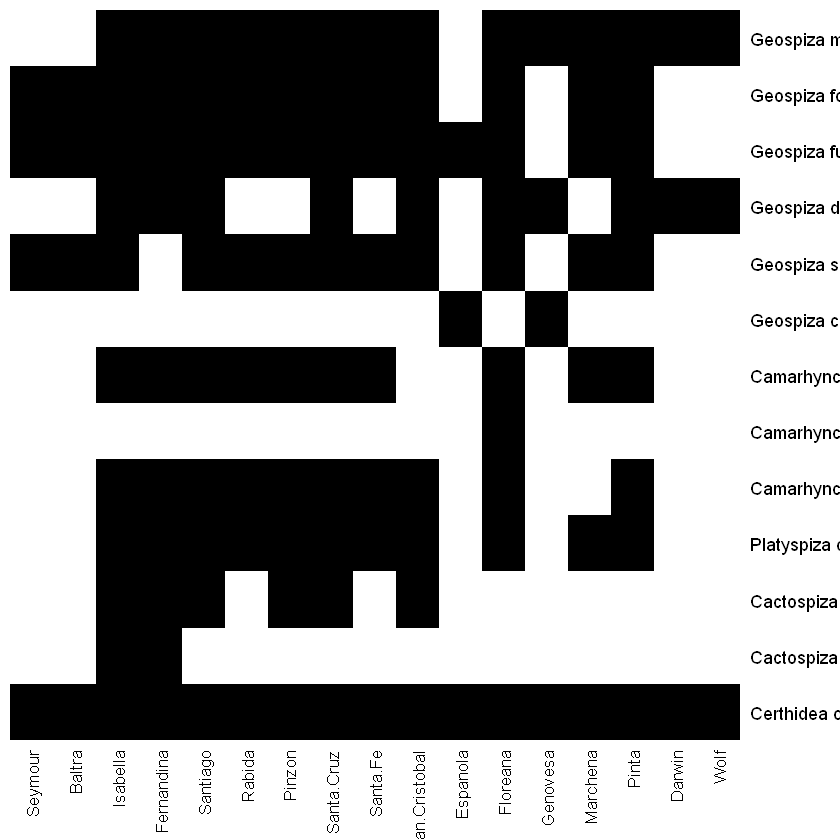

In [84]:
data(finches)
df <- finches

print(df[1:10, 1:5])

heatmap(as.matrix(df)[nrow(df):1, ], col = c("white", "black"), scale = "none",
        Rowv = NA, Colv = NA)

In [85]:
cat("Species:", nrow(df), "\n")
cat("Sites:", ncol(df), "\n")
cat("Total presences:", sum(df), "\n")
cat("Fill percent:", round(sum(df)/(nrow(df)*ncol(df)),2), "\n")
sort(round(rowSums(df)/ncol(df),3), decreasing=TRUE)    # occurrences per species
sort(round(colSums(df)/nrow(df),3), decreasing=TRUE)    # richness per site
c_score(as.matrix(df))

Species: 13 
Sites: 17 
Total presences: 122 
Fill percent: 0.55 


Certhidea olivacea    Geospiza magnirostris      Geospiza fuliginosa 
                   1.000                    0.824                    0.824 
         Geospiza fortis        Geospiza scandens Platyspiza crassirostris 
                   0.765                    0.706                    0.647 
     Geospiza difficilis  Camarhynchus psittacula    Camarhynchus parvulus 
                   0.588                    0.588                    0.588 
      Cactospiza pallida     Geospiza conirostris    Cactospiza heliobates 
                   0.353                    0.118                    0.118 
     Camarhynchus pauper 
                   0.059

Isabella    Fernandina      Santiago    Santa.Cruz      Floreana 
        0.846         0.769         0.769         0.769         0.769 
       Pinzon San.Cristobal         Pinta        Rabida      Santa.Fe 
        0.692         0.692         0.692         0.615         0.615 
     Marchena       Seymour        Baltra      Genovesa      Espanola 
        0.538         0.308         0.308         0.308         0.231 
       Darwin          Wolf 
        0.231         0.231

[1] 4.269231

Burn-in Progress 
  |====                                                                  |   5%
Swap Progress 
  |======================================================================| 100%
Time Stamp:  Tue Apr 21 20:45:00 2026 
Reproducible:  
Number of Replications:  
Elapsed Time:  1.1 secs 
Metric:  c_score 
Algorithm:  sim9 
Observed Index:  4.2692 
Mean Of Simulated Index:  3.1428 
Variance Of Simulated Index:  0.038848 
Lower 95% (1-tail):  2.8846 
Upper 95% (1-tail):  3.5256 
Lower 95% (2-tail):  2.859 
Upper 95% (2-tail):  3.6026 
Lower-tail P >  0.9999 
Upper-tail P <  1e-04 
Observed metric > 10000 simulated metrics 
Observed metric < 0 simulated metrics 
Observed metric = 0 simulated metrics 
Standardized Effect Size (SES):  5.7152 


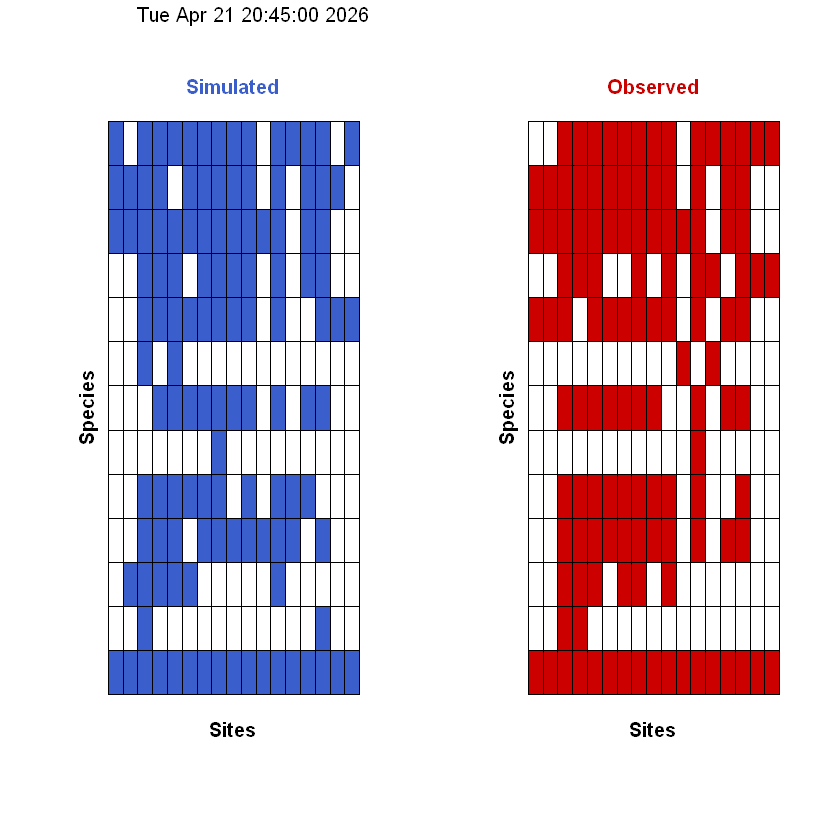

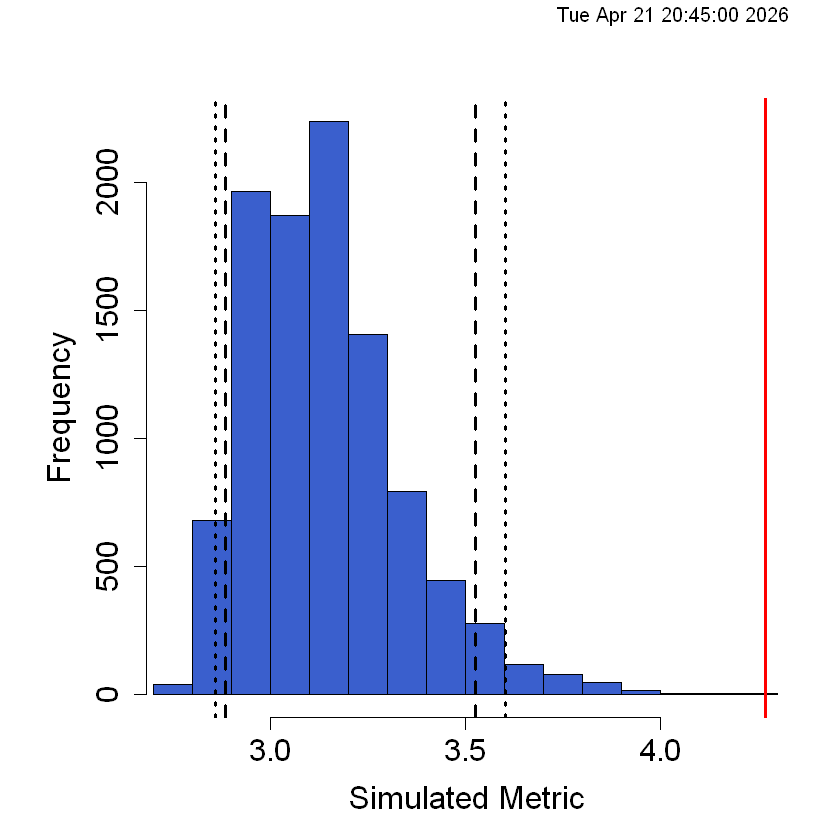

In [86]:
############################
# cooccurence null model
############################
df_cooc <- cbind(ID = rownames(df), df)
rownames(df_cooc) <- NULL
nullMod <- cooc_null_model(df_cooc, algo = "sim9", nReps = 10000)
summary(nullMod)
plot(nullMod, type = "cooc")
plot(nullMod, type = "hist")

## Results: Sanderson (2000) Finches — Demo Dataset

**Significant checkerboard structure detected** — species co-occur less than expected by chance.

| Metric | Value |
|---|---|
| Observed C-score | 4.269 |
| Mean simulated | 3.130 |
| SES | 6.21 |
| P-value (upper-tail) | < 0.0001 |

- Observed C-score exceeded all 10,000 null model replicates (sim9)
- 13 species × 17 islands (slightly smaller matrix than Gotelli & Abele 1982)

**Interpretation:** Finch species are significantly segregated across the 17 sites, consistent with competitive exclusion or island-level habitat partitioning. 

# Pre-carp analysis ($\leq 2007$)

In [88]:
############################
# load data
############################
df <- read.csv("pres_abs.csv", header=TRUE)
ind <- which(df[1,2:ncol(df)] <= 2007)+1 # before breakpoint
df <- df[,c(1,ind)]
colnames(df) <- paste(colnames(df), df[1, ], sep = "_")
df <- df[3:nrow(df), ]
rownames(df) <- df[,1]  
df <- df[, -1]

df <- df[rowSums(df) > 0, ] # remove species with no occurrences
print(df[1:5, 1:5])

     A10A.RS_1997 A10A.RS.1_2003 A12A.RS_1995 A12A.RS.1_2002 A6A.RS_2003
AMEL            0              0            0              0           0
BHCP            0              0            0              0           0
BHMW            0              0            0              0           0
BKBF            0              0            0              0           0
BKBH            0              0            0              0           0


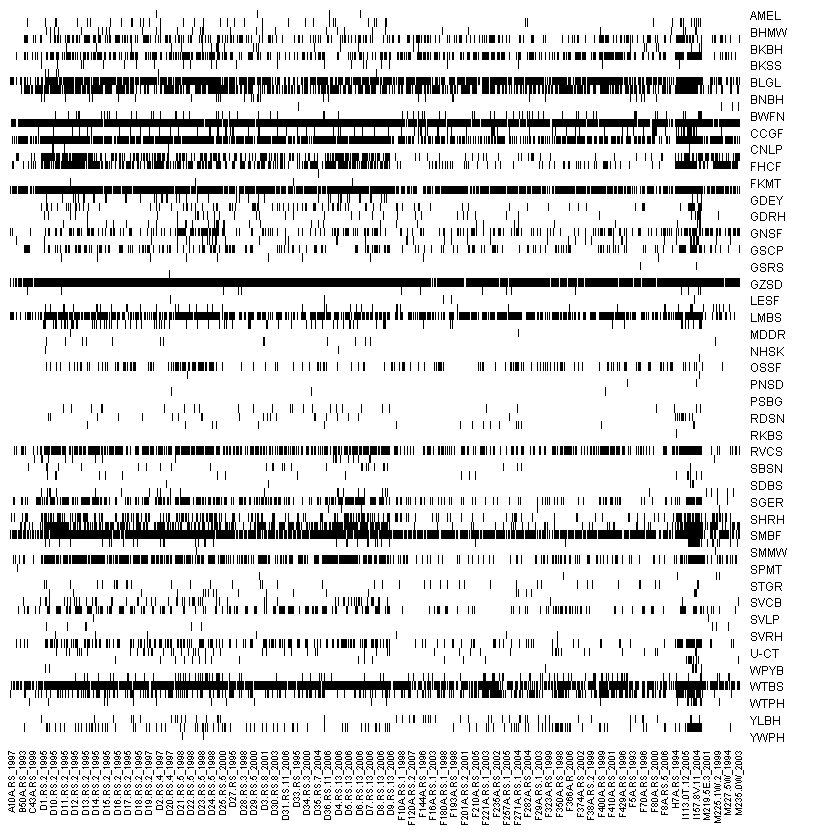

In [89]:

heatmap(as.matrix(df)[nrow(df):1, ], col = c("white", "black"), scale = "none",
        Rowv = NA, Colv = NA)

In [7]:
############################
# summary stats
############################
cat("Species:", nrow(df), "\n")
cat("Sites:", ncol(df), "\n")
cat("Total presences:", sum(df), "\n")
cat("Fill percent:", round(sum(df)/(nrow(df)*ncol(df)),2), "\n")
sort(round(rowSums(df)/ncol(df),3), decreasing=TRUE)    # occurrences per species
sort(round(colSums(df)/nrow(df),3), decreasing=TRUE)[1:5]    # richness per site
c_score(as.matrix(df))

Species: 87 
Sites: 1040 
Total presences: 15751 
Fill percent: 0.17 


GZSD  CARP  SMBF  FWDM  WTBS  BLGL  CNCF  LMBS  BMBF  RVCS  SNGR  BKCP  FHCF 
0.968 0.961 0.874 0.863 0.853 0.792 0.780 0.698 0.650 0.554 0.481 0.475 0.449 
 SJHR  WTCP  SGER  ERSN  GNSF  BKBF  TFSD  SHRH  SVCP  GSCP  OSSF  YWBS  WRMH 
0.422 0.393 0.388 0.367 0.341 0.339 0.294 0.290 0.271 0.268 0.229 0.167 0.135 
 CCGF  GDFH  LNGR  BWFN  SVCB  U-CT  LGPH  SMBS  GDEY  YLBH  BHCP  STGR  GDRH 
0.126 0.123 0.100 0.091 0.089 0.078 0.073 0.071 0.070 0.069 0.061 0.060 0.057 
 GSBG  GDSN  QLBK  BHMW  SBSN  SFSN  BNBH  RDSN  WLYE  BKBH  WTPH  BKSS  RESF 
0.057 0.049 0.049 0.048 0.041 0.039 0.037 0.037 0.036 0.035 0.031 0.030 0.029 
 STSN  RVSN  SBWB  MNEY  HFCS  WPYB  GSPK  SVMW  SDBS  SVRH  BLCF  LESF  CNLP 
0.027 0.025 0.025 0.024 0.020 0.016 0.011 0.010 0.009 0.009 0.008 0.008 0.006 
 FKMT  SHDR  AMEL  BUSK  STCT  PRPH  NTPK  PDFH  PNSD  SMMW  GSRS  GSWM  MDDR 
0.006 0.006 0.005 0.005 0.005 0.004 0.003 0.003 0.003 0.003 0.002 0.002 0.002 
 NHSK  SPMT  SVLP  YWPH  FHMW  PSBG  RKBS  RRDR  WTSK 
0.002 0.002 0.002 0.002 0.001 0.001 0.001 0.001 0.001

I157.8V.14_2007 I157.8V.10_2003  I157.8V.6_1999 I157.8V.12_2005    I80.0.5_2000 
          0.437           0.391           0.368           0.368           0.368

[1] 4420.001

Burn-in Progress 
  |====                                                                  |   5%
Swap Progress 
  |======================================================================| 100%
Time Stamp:  Mon Apr 20 20:54:24 2026 
Reproducible:  
Number of Replications:  
Elapsed Time:  54 secs 
Metric:  c_score 
Algorithm:  sim9 
Observed Index:  4420 
Mean Of Simulated Index:  4414.9 
Variance Of Simulated Index:  63.618 
Lower 95% (1-tail):  4403.1 
Upper 95% (1-tail):  4429.9 
Lower 95% (2-tail):  4400.3 
Upper 95% (2-tail):  4434.9 
Lower-tail P =  0.7707 
Upper-tail P =  0.2293 
Observed metric > 7707 simulated metrics 
Observed metric < 2293 simulated metrics 
Observed metric = 0 simulated metrics 
Standardized Effect Size (SES):  0.63688 


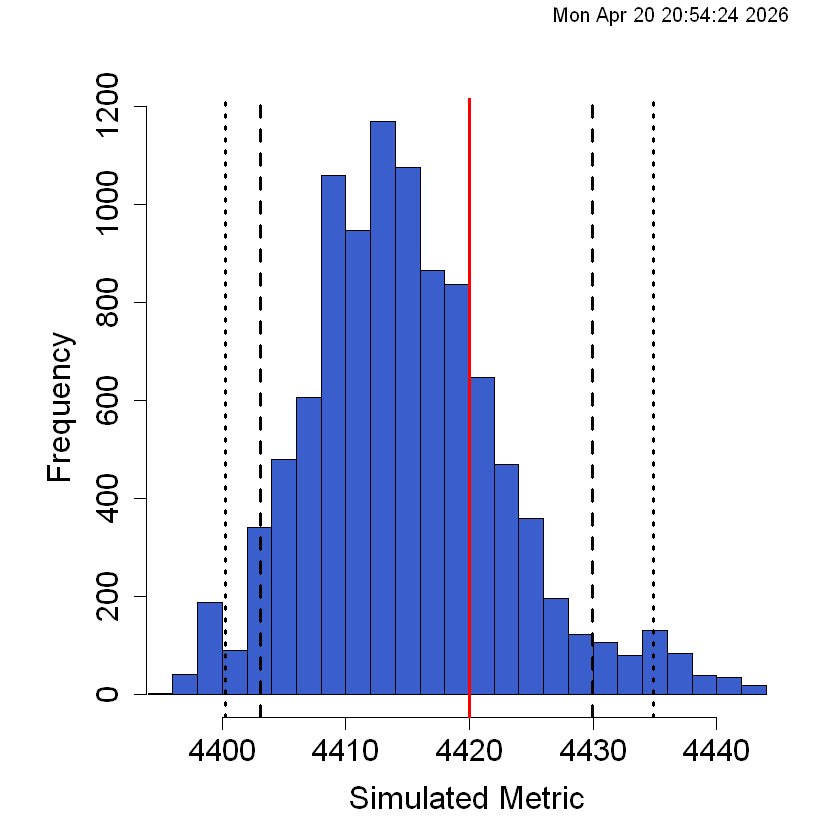

In [8]:
############################
# cooccurence null model
############################
df_cooc <- cbind(ID = rownames(df), df)
rownames(df_cooc) <- NULL
nullMod <- cooc_null_model(df_cooc, algo = "sim9", nReps = 10000)
summary(nullMod)
#plot(nullMod, type = "cooc")
plot(nullMod, type = "hist")

## Results: Pre-Carp Period (≤ 2007)

**No significant co-occurrence structure detected** — species co-occur randomly with respect to sites.

| Metric | Value |
|---|---|
| Observed C-score | 4420 |
| Mean simulated | 4414.9 |
| SES | 0.637 |
| P-value (upper-tail) | 0.229 |

**Interpretation:** Fish communities showed random assembly prior to carp establishment. No evidence of competitive exclusion or habitat partitioning.

# Post-carp analysis ($> 2007$)

In [9]:
############################
# data load
############################
df <- read.csv("pres_abs.csv", header=TRUE)
ind <- which(df[1,2:ncol(df)] > 2007)+1 # after breakpoint
df <- df[,c(1,ind)]
colnames(df) <- paste(colnames(df), df[1, ], sep = "_")
df <- df[3:nrow(df), ]
rownames(df) <- df[,1]  
df <- df[, -1]

df <- df[rowSums(df) > 0, ] # remove species with no occurrences
print(df[1:5, 1:5])

     A11A.RS_2015 A13A.RS_2024 A14A.RS_2011 A19A.RS_2022 A22A.RS_2011
AMEL            0            0            0            0            0
BDKF            0            0            0            0            0
BGOS            0            0            0            0            0
BGRS            0            0            0            0            0
BGWM            0            0            0            0            0


In [10]:

############################
# summary stats
############################
cat("Species:", nrow(df), "\n")
cat("Sites:", ncol(df), "\n")
cat("Total presences:", sum(df), "\n")
cat("Fill percent:", round(sum(df)/(nrow(df)*ncol(df)),2), "\n")
sort(round(rowSums(df)/ncol(df),3), decreasing=TRUE)    # occurrences per species
sort(round(colSums(df)/nrow(df),3), decreasing=TRUE)[1:5]    # richness per site
c_score(as.matrix(df))

Species: 103 
Sites: 1261 
Total presences: 18814 
Fill percent: 0.14 


GZSD  CARP  FWDM  SVCP  SMBF  WTBS  BLGL  CNCF  SNGR  LMBS  BMBF  RVCS  ERSN 
0.924 0.832 0.830 0.789 0.730 0.727 0.723 0.674 0.584 0.581 0.492 0.466 0.452 
 FHCF  BKCP  GSCP  SJHR  LNGR  SGER  GNSF  BKBF  SHRH  OSSF  YWBS  WTCP  TFSD 
0.452 0.397 0.383 0.382 0.362 0.353 0.336 0.287 0.278 0.265 0.246 0.234 0.207 
 U-CT  BWFN  BHMW  SFSN  SVCB  GDFH  STGR  LGPH  SMBS  STSN  GDSN  WRMH  GDEY 
0.148 0.125 0.106 0.087 0.085 0.084 0.076 0.074 0.073 0.073 0.068 0.066 0.064 
 BKSS  RDSN  GDRH  RVSN  SBSN  CCGF  WLYE  QLBK  BHCP  MNEY  WTPH  RESF  GSBG 
0.063 0.063 0.056 0.056 0.051 0.043 0.043 0.036 0.035 0.029 0.029 0.028 0.025 
 BUSK  SMMW  AMEL  BKBH  BLCF  SBWB  FKMT  PNSD  GSPK  BNMW  STCT  BNBH  CLSR 
0.024 0.021 0.016 0.013 0.012 0.011 0.010 0.009 0.008 0.007 0.007 0.006 0.006 
 CNLP  HFCS  LESF  WPYB  WTSK  BGOS  GSOS  SHDR  SVRH  PDFH  SVMW  BDKF  BGRS 
0.006 0.006 0.006 0.006 0.006 0.005 0.005 0.005 0.005 0.004 0.004 0.003 0.003 
 BGWM  GSWM  PSBG  YLBH  BSDR  CNSN  FHMW  NTPK  RDGY  SCBC  SDBS  STBS  U-CN 
0.003 0.003 0.003 0.003 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002 0.002 
 WBYB  BTTM  GSPS  MDDR  MGNP  MQTF  NHSK  PRPH  RRDR  SNSG  SNSN  TPMT 
0.002 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001

D24.RS.15_2008  D23.RS.28_2021   D3.RS.26_2019  D10.RS.26_2019 I157.8Va.7_2015 
           0.34            0.33            0.33            0.32            0.32

[1] 4786.515

Burn-in Progress 
  |====                                                                  |   5%
Swap Progress 
  |======================================================================| 100%
Time Stamp:  Mon Apr 20 20:55:37 2026 
Reproducible:  
Number of Replications:  
Elapsed Time:  1.2 mins 
Metric:  c_score 
Algorithm:  sim9 
Observed Index:  4786.5 
Mean Of Simulated Index:  4802.6 
Variance Of Simulated Index:  89.649 
Lower 95% (1-tail):  4789 
Upper 95% (1-tail):  4819.6 
Lower 95% (2-tail):  4787.9 
Upper 95% (2-tail):  4821.5 
Lower-tail P =  0.0099 
Upper-tail P =  0.9901 
Observed metric > 99 simulated metrics 
Observed metric < 9901 simulated metrics 
Observed metric = 0 simulated metrics 
Standardized Effect Size (SES):  -1.6955 


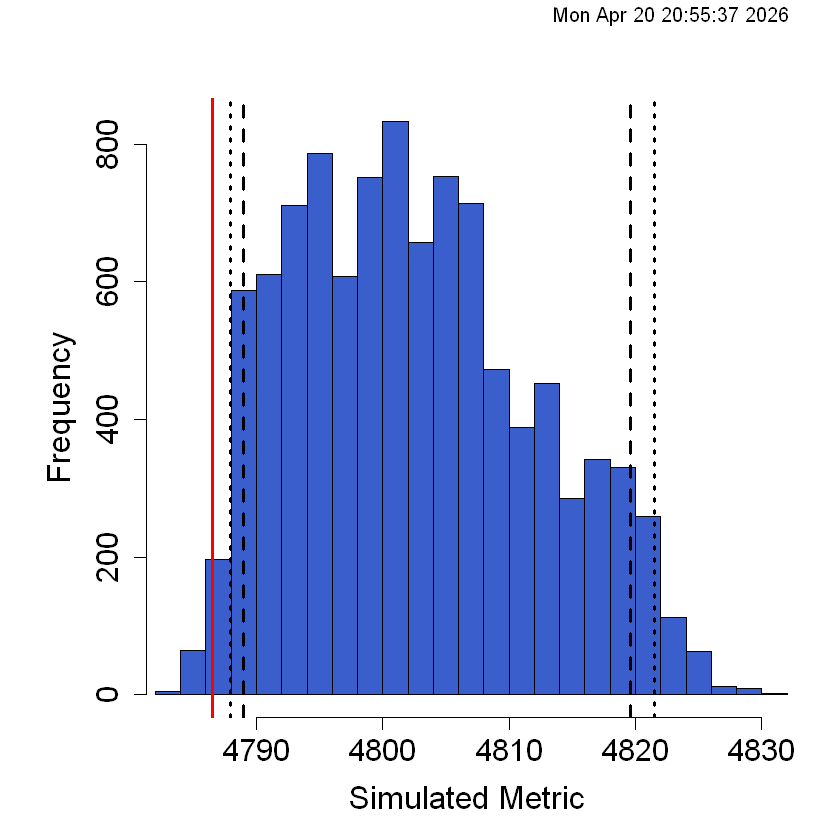

In [11]:
############################
# cooccurence null model
############################
df_cooc <- cbind(ID = rownames(df), df)
rownames(df_cooc) <- NULL
nullMod <- cooc_null_model(df_cooc, algo = "sim9", nReps = 10000)
summary(nullMod)
#plot(nullMod, type = "cooc")
plot(nullMod, type = "hist")

## Results: Post-Carp Period (> 2007)

**Significant aggregation detected** — species co-occur *more* than expected by chance.

| Metric | Value |
|---|---|
| Observed C-score | 4786.5 |
| Mean simulated | 4802.6 |
| SES | −1.70 |
| P-value (lower-tail) | 0.0099 |

**Interpretation:** Post-carp fish communities show significant co-occurrence aggregation — species cluster together at the same sites rather than being segregated. This is the opposite of competitive exclusion. A likely mechanism is habitat homogenization by carp (bioturbation, vegetation loss), funneling species into the same remaining suitable sites.

Contrast with pre-carp (SES = 0.64, P = 0.23): carp invasion appears to have shifted community assembly from random to aggregated co-occurrence.